In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [82]:
Odetails = pd.read_csv(r"C:\Users\Ameen\Desktop\MyProjects-P\Pizza Place Sales\archive (1)\order_details.csv")
Torders = pd.read_csv(r"C:\Users\Ameen\Desktop\MyProjects-P\Pizza Place Sales\archive (1)\orders.csv")
Ptype = pd.read_csv(r"C:\Users\Ameen\Desktop\MyProjects-P\Pizza Place Sales\archive (1)\pizza_types.csv", encoding='windows-1252')
Pizzas = pd.read_csv(r"C:\Users\Ameen\Desktop\MyProjects-P\Pizza Place Sales\archive (1)\pizzas.csv")

In [83]:
m1 = pd.merge(Odetails , Pizzas , on = "pizza_id" , how = "left")
m2 = m1.merge(Torders , on = "order_id" , how = "left")
df = m2.merge(Ptype , on = "pizza_type_id" , how = "left")
df

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,date,time,name,category,ingredients
0,1,1,hawaiian_m,1,hawaiian,M,13.25,2015-01-01,11:38:36,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,2015-01-01,11:57:40,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,five_cheese,L,18.50,2015-01-01,11:57:40,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,ital_supr,L,20.75,2015-01-01,11:57:40,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,mexicana,M,16.00,2015-01-01,11:57:40,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,ckn_alfredo,M,16.75,2015-12-31,21:23:10,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,48617,21348,four_cheese_l,1,four_cheese,L,17.95,2015-12-31,21:23:10,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,48618,21348,napolitana_s,1,napolitana,S,12.00,2015-12-31,21:23:10,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,48619,21349,mexicana_l,1,mexicana,L,20.25,2015-12-31,22:09:54,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [84]:
df.isnull().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
date                0
time                0
name                0
category            0
ingredients         0
dtype: int64

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   pizza_type_id     48620 non-null  object 
 5   size              48620 non-null  object 
 6   price             48620 non-null  float64
 7   date              48620 non-null  object 
 8   time              48620 non-null  object 
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [86]:
df["total_price"] = df["price"] * df["quantity"]

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month_name()
df["day_name"] = df["date"].dt.day_name()

df['time'] = pd.to_datetime(df['time'] , format = '%H:%M:%S').dt.time
df['hour'] = pd.to_datetime(df['time'].astype(str)).dt.hour

def get_time_period(hour):
    if 11 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 20:
        return 'Evening'
    elif 20 <= hour <= 23:
        return 'Night'
    else:
        return 'Morning/Late Night'

df['time_period'] = df['hour'].apply(get_time_period)

df

C:\Users\Ameen\AppData\Local\Temp\ipykernel_25404\382038953.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['time'].astype(str)).dt.hour


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,date,time,name,category,ingredients,total_price,month,day_name,hour,time_period
0,1,1,hawaiian_m,1,hawaiian,M,13.25,2015-01-01,11:38:36,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,January,Thursday,11,Afternoon
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,2015-01-01,11:57:40,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,January,Thursday,11,Afternoon
2,3,2,five_cheese_l,1,five_cheese,L,18.50,2015-01-01,11:57:40,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,January,Thursday,11,Afternoon
3,4,2,ital_supr_l,1,ital_supr,L,20.75,2015-01-01,11:57:40,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,January,Thursday,11,Afternoon
4,5,2,mexicana_m,1,mexicana,M,16.00,2015-01-01,11:57:40,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,January,Thursday,11,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,ckn_alfredo,M,16.75,2015-12-31,21:23:10,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",16.75,December,Thursday,21,Night
48616,48617,21348,four_cheese_l,1,four_cheese,L,17.95,2015-12-31,21:23:10,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",17.95,December,Thursday,21,Night
48617,48618,21348,napolitana_s,1,napolitana,S,12.00,2015-12-31,21:23:10,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",12.00,December,Thursday,21,Night
48618,48619,21349,mexicana_l,1,mexicana,L,20.25,2015-12-31,22:09:54,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",20.25,December,Thursday,22,Night


In [87]:
busiest_period = df.groupby("time_period")["total_price"].sum().sort_values(ascending=False)
busiest_period

time_period
Afternoon             375073.10
Evening               318218.60
Night                 124181.70
Morning/Late Night       386.65
Name: total_price, dtype: float64

In [88]:
most_wanted = df.groupby("name")["quantity"].sum().sort_values(ascending=False)
most_wanted

name
The Classic Deluxe Pizza                      2453
The Barbecue Chicken Pizza                    2432
The Hawaiian Pizza                            2422
The Pepperoni Pizza                           2418
The Thai Chicken Pizza                        2371
The California Chicken Pizza                  2370
The Sicilian Pizza                            1938
The Spicy Italian Pizza                       1924
The Southwest Chicken Pizza                   1917
The Big Meat Pizza                            1914
The Four Cheese Pizza                         1902
The Italian Supreme Pizza                     1884
The Vegetables + Vegetables Pizza             1526
The Mexicana Pizza                            1484
The Napolitana Pizza                          1464
The Prosciutto and Arugula Pizza              1457
The Spinach and Feta Pizza                    1446
The Pepper Salami Pizza                       1446
The Italian Capocollo Pizza                   1438
The Greek Pizza           

In [89]:
busiest_days = df.groupby('day_name')['total_price'].sum().sort_values(ascending=False)
busiest_days

day_name
Friday       136073.90
Thursday     123528.50
Saturday     123182.40
Wednesday    114408.40
Tuesday      114133.80
Monday       107329.55
Sunday        99203.50
Name: total_price, dtype: float64

In [90]:
sns.set_theme(style="whitegrid")

C:\Users\Ameen\AppData\Local\Temp\ipykernel_25404\503762212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_period.index , y=revenue_by_period.values , palette="viridis")


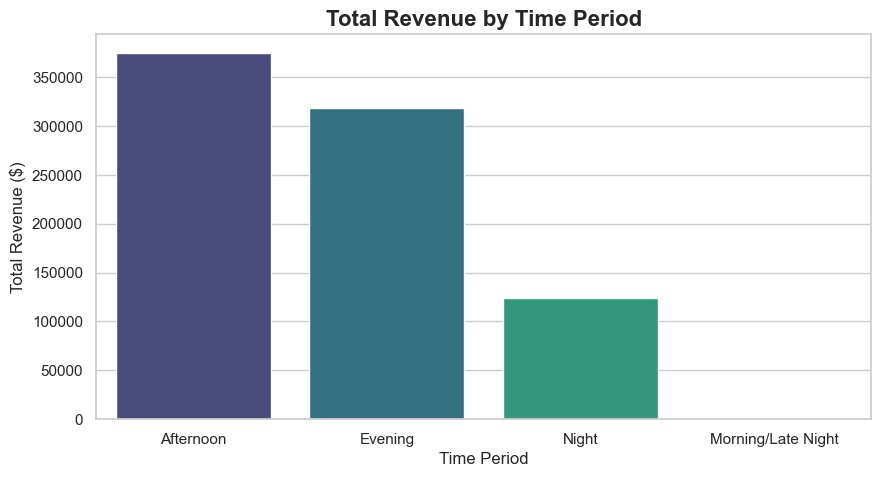

In [91]:
plt.figure(figsize=(10, 5))

revenue_by_period = df.groupby('time_period')['total_price'].sum().sort_values(ascending=False)

sns.barplot(x=revenue_by_period.index , y=revenue_by_period.values , palette="viridis")

plt.title('Total Revenue by Time Period' , fontsize=16 , fontweight='bold')
plt.xlabel('Time Period' , fontsize=12)
plt.ylabel('Total Revenue ($)' , fontsize=12)

# عرض الرسم
plt.show()

C:\Users\Ameen\AppData\Local\Temp\ipykernel_25404\3713078102.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_day.index , y=revenue_by_day.values , palette="crest")


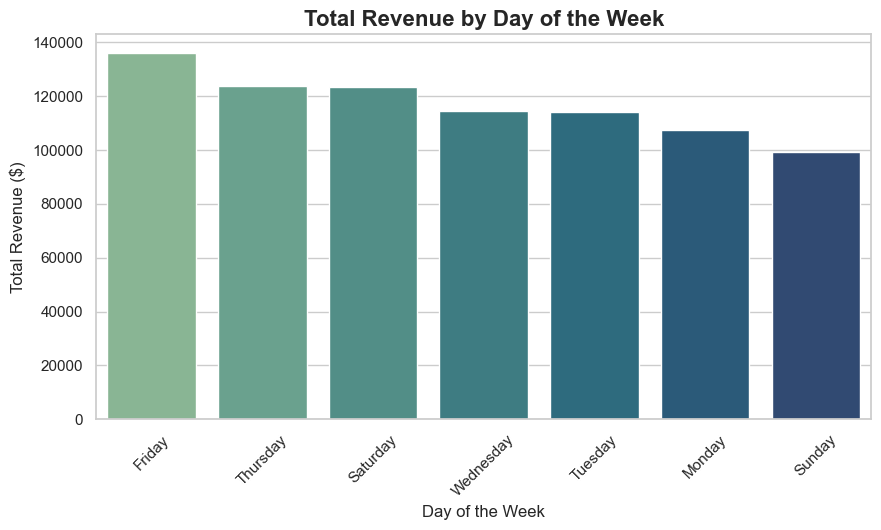

In [92]:
plt.figure(figsize=(10, 5))

revenue_by_day = df.groupby('day_name')['total_price'].sum().sort_values(ascending=False)

sns.barplot(x=revenue_by_day.index , y=revenue_by_day.values , palette="crest")

plt.title('Total Revenue by Day of the Week' , fontsize=16 , fontweight='bold')
plt.xlabel('Day of the Week' , fontsize=12)
plt.ylabel('Total Revenue ($)' , fontsize=12)
plt.xticks(rotation=45)  

# عرض الرسم
plt.show()

C:\Users\Ameen\AppData\Local\Temp\ipykernel_25404\2838274647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_pizzas.values , y=top_5_pizzas.index , palette="magma")


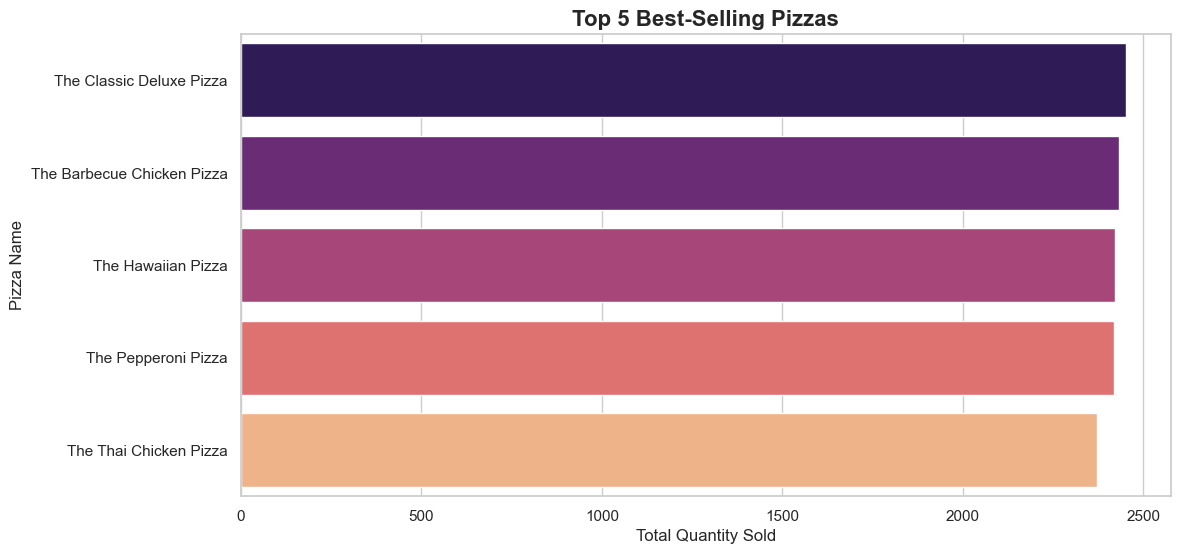

In [93]:
plt.figure(figsize=(12 , 6))

top_5_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)

sns.barplot(x=top_5_pizzas.values , y=top_5_pizzas.index , palette="magma")

plt.title('Top 5 Best-Selling Pizzas' , fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Sold' , fontsize=12)
plt.ylabel('Pizza Name' , fontsize=12)

# عرض الرسم
plt.show()

In [94]:
basket = pd.crosstab(df['order_id'] , df['name'])
basket = basket.map(lambda x: 1 if x > 0 else 0)

frequent_itemsets = apriori(basket , min_support  = 0.01 , use_colnames = True)

rules = association_rules(frequent_itemsets , metric = "lift" , min_threshold = 1.0)
rules = rules.sort_values(by =  'lift' , ascending = False)

rules.head(10)

c:\Users\Ameen\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
36,(The Pepperoni Pizza),(The Four Cheese Pizza),0.106698,0.084731,0.011007,0.103161,1.217513,1.0,0.001966,1.020550,0.199992,0.061007,0.020136,0.116533
37,(The Four Cheese Pizza),(The Pepperoni Pizza),0.084731,0.106698,0.011007,0.129906,1.217513,1.0,0.001966,1.026673,0.195192,0.061007,0.025980,0.116533
12,(The Big Meat Pizza),(The Thai Chicken Pizza),0.084824,0.104215,0.010398,0.122584,1.176257,1.0,0.001558,1.020935,0.163735,0.058207,0.020506,0.111180
13,(The Thai Chicken Pizza),(The Big Meat Pizza),0.104215,0.084824,0.010398,0.099775,1.176257,1.0,0.001558,1.016608,0.167279,0.058207,0.016337,0.111180
27,(The Classic Deluxe Pizza),(The Italian Supreme Pizza),0.109087,0.083888,0.010539,0.096608,1.151636,1.0,0.001388,1.014081,0.147792,0.057766,0.013885,0.111118
26,(The Italian Supreme Pizza),(The Classic Deluxe Pizza),0.083888,0.109087,0.010539,0.125628,1.151636,1.0,0.001388,1.018918,0.143727,0.057766,0.018567,0.111118
49,(The Thai Chicken Pizza),(The Southwest Chicken Pizza),0.104215,0.085480,0.010164,0.097528,1.140945,1.0,0.001256,1.013350,0.137905,0.056614,0.013174,0.108216
48,(The Southwest Chicken Pizza),(The Thai Chicken Pizza),0.085480,0.104215,0.010164,0.118904,1.140945,1.0,0.001256,1.016671,0.135080,0.056614,0.016398,0.108216
40,(The Hawaiian Pizza),(The Thai Chicken Pizza),0.106792,0.104215,0.012646,0.118421,1.136310,1.0,0.001517,1.016114,0.134301,0.063754,0.015858,0.119885
41,(The Thai Chicken Pizza),(The Hawaiian Pizza),0.104215,0.106792,0.012646,0.121348,1.136310,1.0,0.001517,1.016567,0.133914,0.063754,0.016297,0.119885


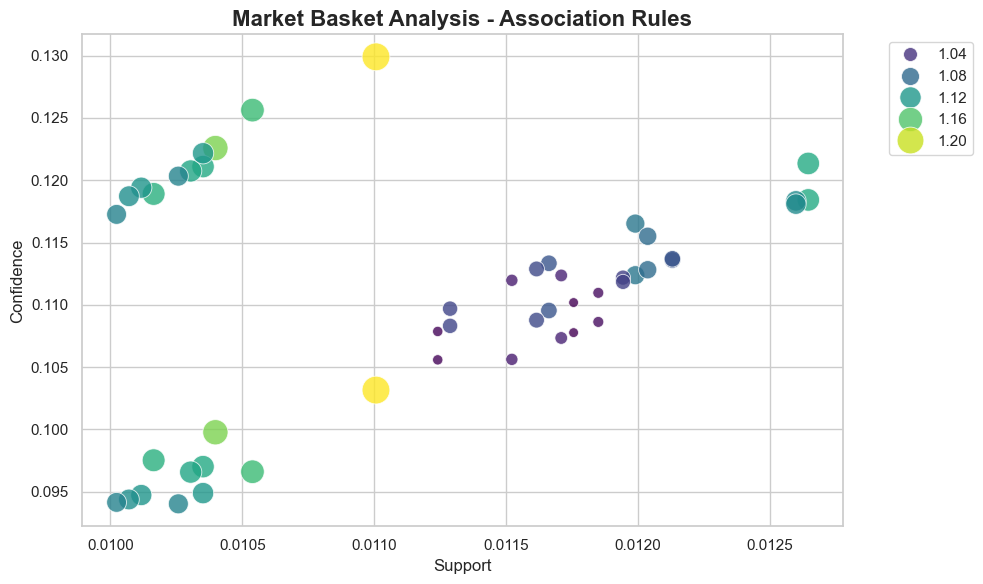

In [95]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=rules , 
                x="support" , 
                y="confidence" , 
                size="lift" , 
                hue="lift" , 
                sizes=(50, 400) , 
                palette="viridis" , 
                alpha=0.8) 

plt.title('Market Basket Analysis - Association Rules' , fontsize=16 , fontweight='bold')
plt.xlabel('Support' , fontsize=12)
plt.ylabel('Confidence' , fontsize=12)

plt.legend(bbox_to_anchor=(1.05 , 1) , loc='upper left')
plt.tight_layout()

plt.show()

In [96]:
print(rules[['antecedents' , 'consequents' , 'support' , 'confidence' , 'lift']])

                       antecedents                     consequents   support  \
36           (The Pepperoni Pizza)         (The Four Cheese Pizza)  0.011007   
37         (The Four Cheese Pizza)           (The Pepperoni Pizza)  0.011007   
12            (The Big Meat Pizza)        (The Thai Chicken Pizza)  0.010398   
13        (The Thai Chicken Pizza)            (The Big Meat Pizza)  0.010398   
27      (The Classic Deluxe Pizza)     (The Italian Supreme Pizza)  0.010539   
26     (The Italian Supreme Pizza)      (The Classic Deluxe Pizza)  0.010539   
49        (The Thai Chicken Pizza)   (The Southwest Chicken Pizza)  0.010164   
48   (The Southwest Chicken Pizza)        (The Thai Chicken Pizza)  0.010164   
40            (The Hawaiian Pizza)        (The Thai Chicken Pizza)  0.012646   
41        (The Thai Chicken Pizza)            (The Hawaiian Pizza)  0.012646   
43   (The Southwest Chicken Pizza)           (The Pepperoni Pizza)  0.010351   
42           (The Pepperoni Pizza)   (Th

In [ ]:
df.to_csv('final_data.csv' , index=False)